In [ ]:
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
!kaggle competitions download -c playground-series-s6e7
!unzip playground-series-s6e7.zip -d /content/dataset

playground-series-s6e7.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  playground-series-s6e7.zip
replace /content/dataset/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
df = pd.read_csv("dataset/train.csv")
le = LabelEncoder()

In [ ]:
X = df.drop(columns=["health_condition"])

y = df["health_condition"]


In [ ]:
X["stress_level"] = le.fit_transform(X["stress_level"])
X["sleep_quality"] = le.fit_transform(X["sleep_quality"])
X["physical_activity_level"] = le.fit_transform(X["physical_activity_level"])
X["smoking_alcohol"] = le.fit_transform(X["smoking_alcohol"])
X["gender"] = le.fit_transform(X["gender"])
X["diet_type"] = le.fit_transform(X["diet_type"])
y = le.fit_transform(y)

In [ ]:
X.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,0,0,2,2,0
1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,2,2
2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,2,0,2,1
3,3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,0,0,0,1,0
4,4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,2,3,0,2,3,1


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
scaler = StandardScaler()


In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=500,
    max_leaf_nodes=103,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=0,
    verbose=1
)

In [ ]:
model.fit(X_train,y_train)


Binning 0.056 GB of training data: 0.449 s
Binning 0.006 GB of validation data: 0.037 s
Fitting gradient boosted rounds:
Fit 132 trees in 12.241 s, (13596 total leaves)
Time spent computing histograms: 5.478s
Time spent finding best splits:  0.646s
Time spent applying splits:      1.854s
Time spent predicting:           0.224s


HistGradientBoostingClassifier(early_stopping=True, max_iter=500,
                               max_leaf_nodes=103, random_state=0, verbose=1)

In [ ]:
pred = model.predict(X_test)

In [ ]:
accuracy_score(y_test,pred)

0.9659029981596603

In [ ]:
model.score(X_test,y_test)

0.9659029981596603

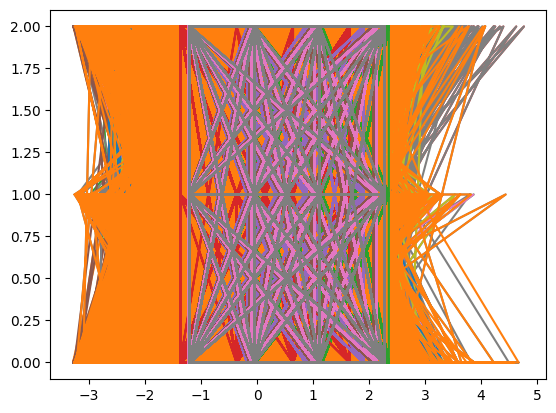

In [ ]:
plt.plot(X_test,y_test)
plt.plot(X_test,pred)
plt.show()

In [ ]:
model.fit(X,y)

Binning 0.070 GB of training data: 0.525 s
Binning 0.008 GB of validation data: 0.045 s
Fitting gradient boosted rounds:
Fit 120 trees in 14.141 s, (12360 total leaves)
Time spent computing histograms: 6.543s
Time spent finding best splits:  0.620s
Time spent applying splits:      2.144s
Time spent predicting:           0.281s


HistGradientBoostingClassifier(early_stopping=True, max_iter=500,
                               max_leaf_nodes=103, random_state=0, verbose=1)

In [ ]:
model.score(X,y)

0.9707341672366423

In [ ]:
test_df = pd.read_csv("dataset/test.csv")

In [ ]:
test_features = test_df.copy()

test_features["stress_level"] = LabelEncoder().fit_transform(test_features["stress_level"])
test_features["sleep_quality"] = LabelEncoder().fit_transform(test_features["sleep_quality"])
test_features["physical_activity_level"] = LabelEncoder().fit_transform(test_features["physical_activity_level"])
test_features["smoking_alcohol"] = LabelEncoder().fit_transform(test_features["smoking_alcohol"])
test_features["gender"] = LabelEncoder().fit_transform(test_features["gender"])
test_features["diet_type"] = LabelEncoder().fit_transform(test_features["diet_type"])

scaled_test_features = scaler.transform(test_features)

predictions_for_submission = model.predict(scaled_test_features)

predictions_for_submission = le.inverse_transform(predictions_for_submission)


submission = pd.DataFrame({
    "id": test_df["id"],
    "Health_Risk": predictions_for_submission
})

submission.to_csv("submission.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!kaggle competitions submit -c playground-series-s6e7 -f submission.csv -m "another model 2"


100% 3.69M/3.69M [00:00<00:00, 4.75MB/s]
Successfully submitted to Predicting Student Health Risk